In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("dataset/Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [8]:
df = df[['Order Date', 'Sales']]

In [9]:
df = df.groupby('Order Date')['Sales'].sum().reset_index()
df.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [10]:
df = df.sort_values('Order Date')

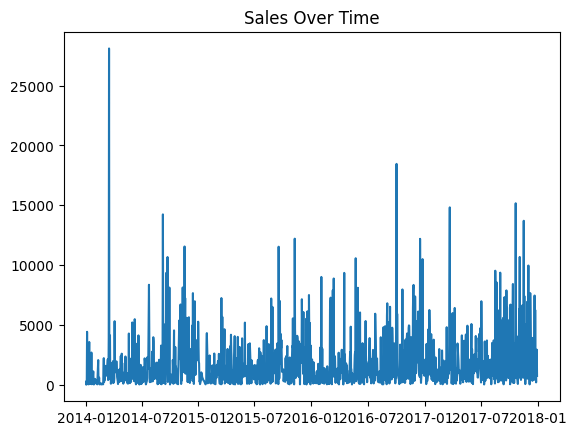

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df['Order Date'], df['Sales'])
plt.title("Sales Over Time")
plt.show()

In [12]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

df.head()

,Order Date,Sales,Year,Month,Day,DayOfWeek
0,2014-01-03,16.448,2014,1,3,4
1,2014-01-04,288.060,2014,1,4,5
2,2014-01-05,19.536,2014,1,5,6
3,2014-01-06,4407.100,2014,1,6,0
4,2014-01-07,87.158,2014,1,7,1


In [13]:
X = df[['Year', 'Month', 'Day', 'DayOfWeek']]
y = df['Sales']

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
future_dates = pd.date_range(start='2018-01-01', periods=30)

future_df = pd.DataFrame({
    'Year': future_dates.year,
    'Month': future_dates.month,
    'Day': future_dates.day,
    'DayOfWeek': future_dates.dayofweek
})

predictions = model.predict(future_df)

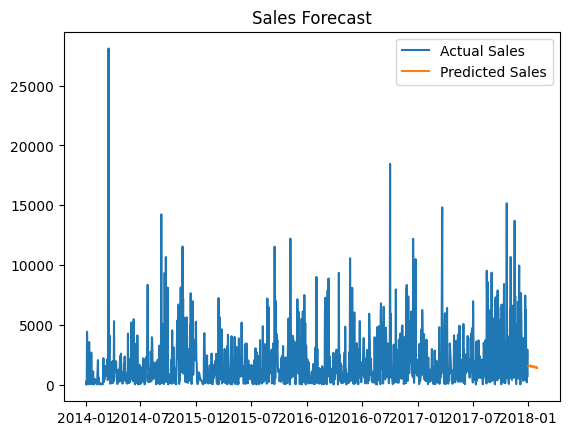

In [16]:
import matplotlib.pyplot as plt

plt.figure()

# past data
plt.plot(df['Order Date'], y, label='Actual Sales')

# future prediction
plt.plot(future_dates, predictions, label='Predicted Sales')

plt.legend()
plt.title("Sales Forecast")
plt.show()

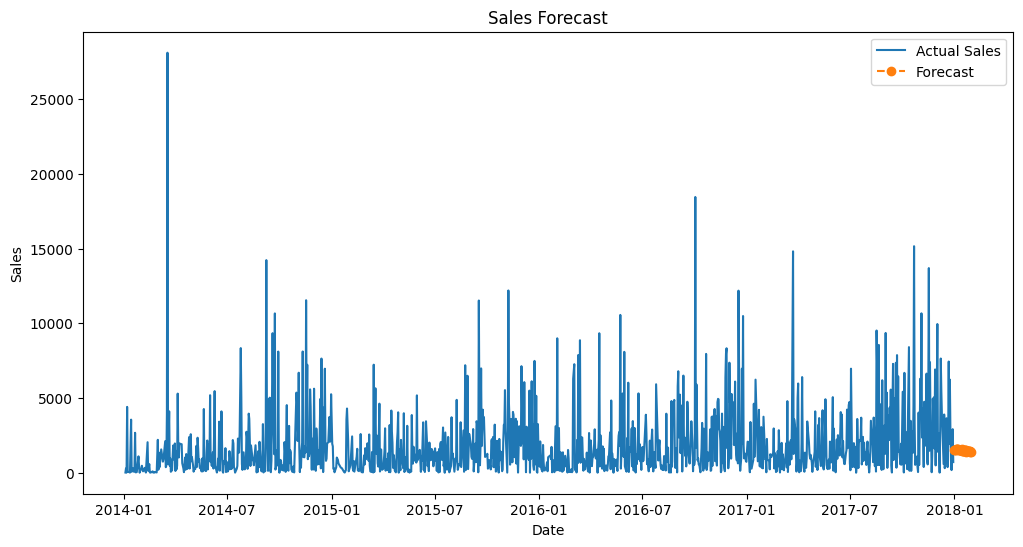

In [17]:
plt.figure(figsize=(12,6))

plt.plot(df['Order Date'], y, label='Actual Sales')
plt.plot(future_dates, predictions, label='Forecast', linestyle='dashed', marker='o')

plt.legend()
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

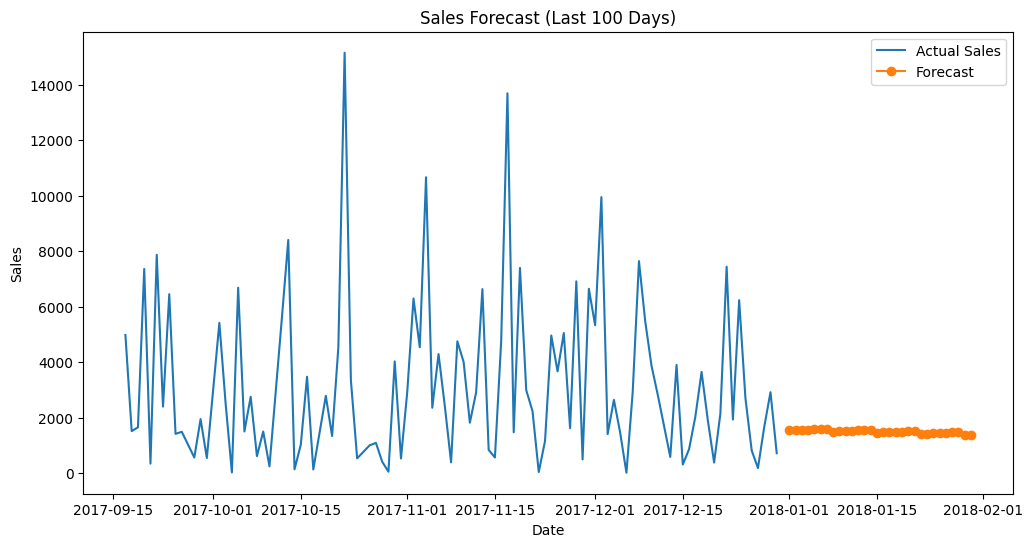

In [18]:
plt.figure(figsize=(12,6))

# last 100 days only (clean view)
plt.plot(df['Order Date'][-100:], y[-100:], label='Actual Sales')
plt.plot(future_dates, predictions, label='Forecast', marker='o')

plt.legend()
plt.title("Sales Forecast (Last 100 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X)
print("MAE:", mean_absolute_error(y, pred))

MAE: 1463.252729914467


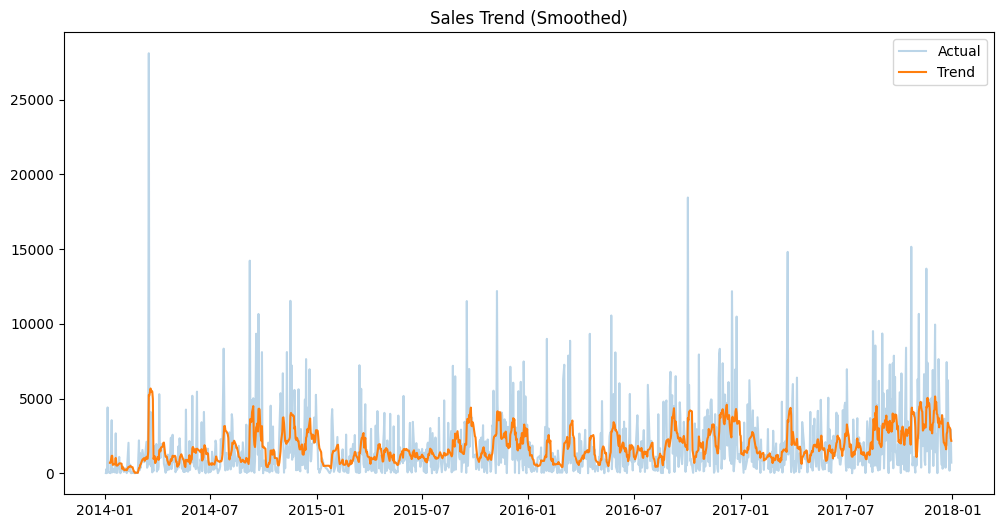

In [20]:
df['RollingAvg'] = df['Sales'].rolling(7).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Order Date'], df['Sales'], alpha=0.3, label='Actual')
plt.plot(df['Order Date'], df['RollingAvg'], label='Trend')

plt.legend()
plt.title("Sales Trend (Smoothed)")
plt.show()